# **ASSIGNMENT-13:DECISION TREE**

# Objective:The objective of this assignment is to apply Decision Tree Classification to a given dataset, analyse the performance of the model, and interpret the results.

# **Tasks:**

# **1.) Data Preparation:**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder,StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score,classification_report,roc_curve,roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).

In [2]:
df=pd.read_excel('heart_disease.xlsx',sheet_name='Heart_disease')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,reversable defect,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,normal,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,fixed defect,4


# **2.) Exploratory Data Analysis (EDA):**

# Perform exploratory data analysis to understand the structure of the dataset.

In [3]:
df.shape

(908, 13)

In [4]:
df.size

11804

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,908.0,53.791850,9.158031,29.0,47.75,54.0,60.0,77.0
trestbps,908.0,133.430617,20.401608,0.0,120.00,130.0,144.0,200.0
chol,908.0,201.484581,112.097949,0.0,176.75,224.0,270.0,603.0
thalch,908.0,135.957048,26.804929,60.0,118.00,138.0,156.0,202.0
oldpeak,846.0,0.891253,1.093875,-2.6,0.00,0.5,1.5,6.2
num,908.0,1.008811,1.144436,0.0,0.00,1.0,2.0,4.0


# Check for missing values, outliers, and inconsistencies in the data.

In [7]:
# Missing Values
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [8]:
df['oldpeak'].fillna(df['oldpeak'].mean(),inplace=True)
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [9]:
# Checking Duplicates
df.duplicated().sum()

np.int64(1)

In [10]:
# Removing Duplicates
df.drop_duplicates(inplace=True,ignore_index=True)
df.duplicated().sum()

np.int64(0)

In [11]:
features= df.drop(columns='num')
features

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.300000,downsloping,fixed defect
1,41,Male,atypical angina,135,203,False,normal,132,False,0.000000,flat,fixed defect
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.400000,flat,fixed defect
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.000000,flat,fixed defect
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.500000,flat,fixed defect
...,...,...,...,...,...,...,...,...,...,...,...,...
902,53,Male,asymptomatic,125,0,False,normal,120,False,1.500000,upsloping,reversable defect
903,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.000000,flat,reversable defect
904,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.500000,downsloping,normal
905,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,0.891253,downsloping,fixed defect


In [12]:
num_features=features.select_dtypes('number')
num_features

,age,trestbps,chol,thalch,oldpeak
0,63,145,233,150,2.300000
1,41,135,203,132,0.000000
2,57,140,192,148,0.400000
3,52,118,186,190,0.000000
4,57,110,201,126,1.500000
...,...,...,...,...,...
902,53,125,0,120,1.500000
903,62,166,170,120,3.000000
904,56,170,0,123,2.500000
905,56,144,208,105,0.891253


In [13]:
target=df[['num']]
target

,num
0,0
1,0
2,0
3,0
4,0
...,...
902,4
903,4
904,4
905,4


In [14]:
# Inconsistancies observed and rectified in the data.
features['fbs']=features['fbs'].astype(int)
features['exang']=(features['exang']
               .astype(str)      # handle mixed boolean & string values
               .str.strip()      # remove extra spaces
               .str.upper()      # standardize case
               .replace({'TURE': 'TRUE'})  # fix spelling mistake
)
features['exang']=features['exang'].map({'TRUE':1,'FALSE':0})
features['sex']=features['sex'].map({'Male': 1, 'Female': 0})

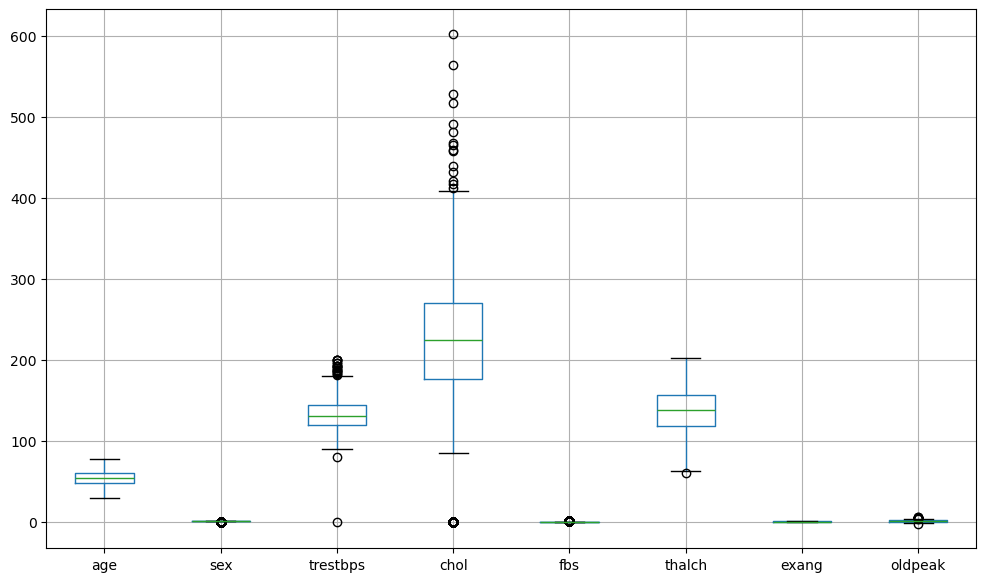

In [15]:
# Outliers
features.boxplot(figsize=(12,7))
plt.show()

In [16]:
# Removing Outliers
def outlier_capping(df,columns):
    Q1=df[columns].quantile(0.25)
    Q3=df[columns].quantile(0.75)
    IQR=Q3-Q1
    Lower_Extreme=Q1-1.5*IQR
    Upper_Extreme=Q3+1.5*IQR
    df[columns]=df[columns].apply(lambda x:Lower_Extreme if x<Lower_Extreme else Upper_Extreme if x>Upper_Extreme else x)
for col in features.select_dtypes(['int','float']).columns:
    outlier_capping(features,col)

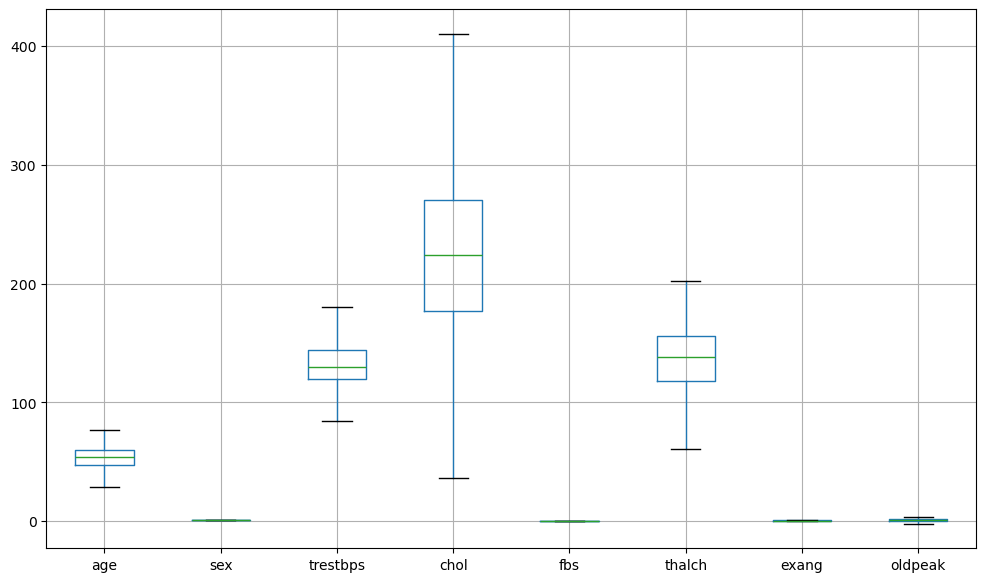

In [17]:
features.boxplot(figsize=(12,7))
plt.show()

# Visualize the distribution of features, including histograms, box plots, and correlation matrices.

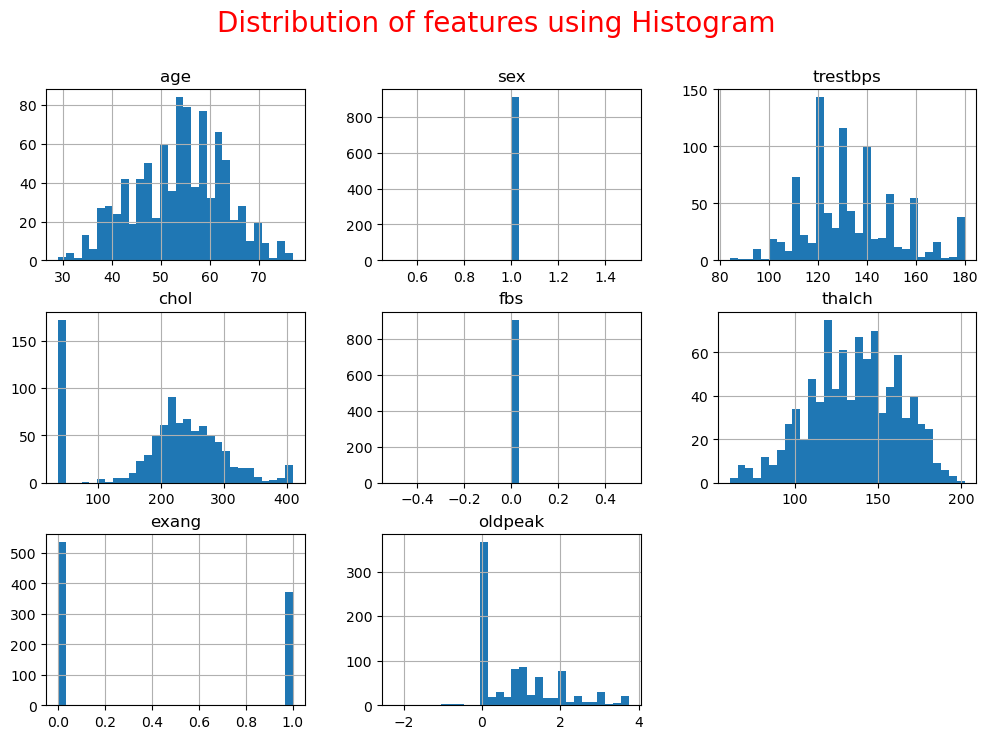

In [18]:
# Histogram
features.hist(figsize=(12,8),bins=30)
plt.suptitle('Distribution of features using Histogram',fontsize=20,color='red')
plt.show()

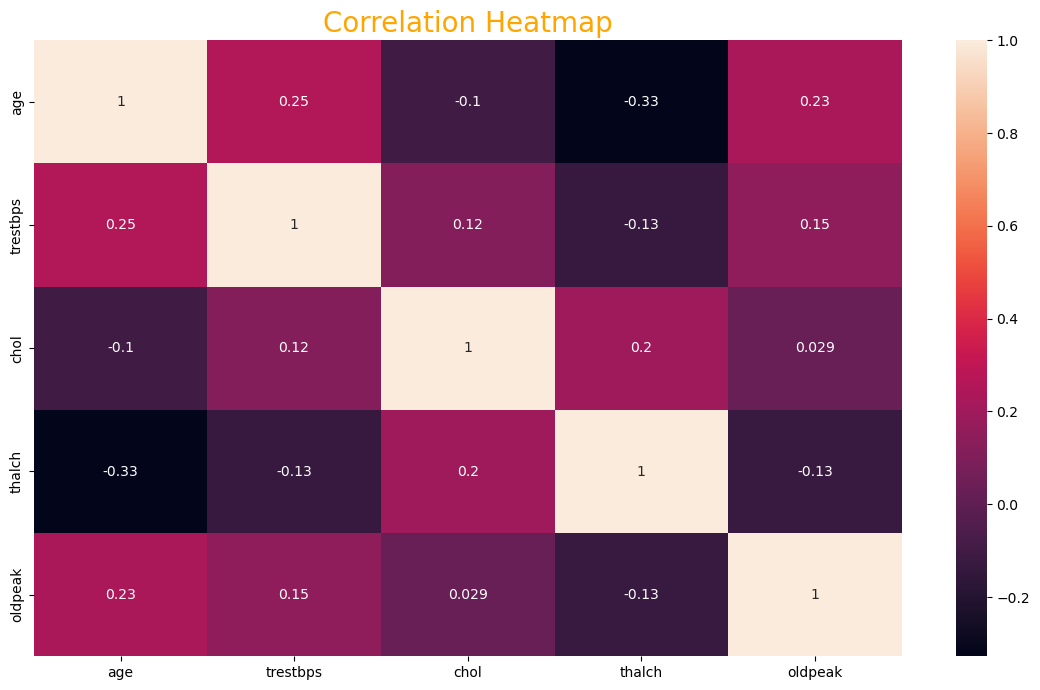

In [19]:
# Correlation Heatmap
plt.figure(figsize=(14,8))
sns.heatmap(num_features.corr(),annot=True)
plt.title('Correlation Heatmap',fontsize=20,color='orange')
plt.show()

# **3.) Feature Engineering:**

# If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.

In [20]:
features.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal
0,63,1.0,typical angina,145.0,233.0,0.0,lv hypertrophy,150.0,0,2.3,downsloping,fixed defect
1,41,1.0,atypical angina,135.0,203.0,0.0,normal,132.0,0,0.0,flat,fixed defect
2,57,1.0,asymptomatic,140.0,192.0,0.0,normal,148.0,0,0.4,flat,fixed defect
3,52,1.0,typical angina,118.0,186.0,0.0,lv hypertrophy,190.0,0,0.0,flat,fixed defect
4,57,1.0,asymptomatic,110.0,201.0,0.0,normal,126.0,1,1.5,flat,fixed defect


In [21]:
# Encoding using one-hot encoder
features = pd.get_dummies(features,columns=['cp','restecg','thal'],drop_first=True,dtype=int)

In [22]:
# Encoding using ordinal encoder
ord_enc=OrdinalEncoder()
features['slope']=ord_enc.fit_transform(features[['slope']])

In [23]:
features

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,slope,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,thal_normal,thal_reversable defect
0,63,1.0,145.0,233.00,0.0,150.0,0,2.300000,0.0,0,0,1,0,0,0,0
1,41,1.0,135.0,203.00,0.0,132.0,0,0.000000,1.0,1,0,0,1,0,0,0
2,57,1.0,140.0,192.00,0.0,148.0,0,0.400000,1.0,0,0,0,1,0,0,0
3,52,1.0,118.0,186.00,0.0,190.0,0,0.000000,1.0,0,0,1,0,0,0,0
4,57,1.0,110.0,201.00,0.0,126.0,1,1.500000,1.0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
902,53,1.0,125.0,36.25,0.0,120.0,0,1.500000,2.0,0,0,0,1,0,0,1
903,62,1.0,166.0,170.00,0.0,120.0,1,3.000000,1.0,0,0,0,0,1,0,1
904,56,1.0,170.0,36.25,0.0,123.0,1,2.500000,0.0,0,1,0,0,0,1,0
905,56,1.0,144.0,208.00,0.0,105.0,1,0.891253,0.0,0,1,0,0,1,0,0


In [24]:
# Scaling only the numerical features
std_slr=StandardScaler()
num_features

,age,trestbps,chol,thalch,oldpeak
0,63,145,233,150,2.300000
1,41,135,203,132,0.000000
2,57,140,192,148,0.400000
3,52,118,186,190,0.000000
4,57,110,201,126,1.500000
...,...,...,...,...,...
902,53,125,0,120,1.500000
903,62,166,170,120,3.000000
904,56,170,0,123,2.500000
905,56,144,208,105,0.891253


In [25]:
features[['age','trestbps','chol','thalch','oldpeak']]=std_slr.fit_transform(features[['age','trestbps','chol','thalch','oldpeak']])
features

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,slope,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,thal_normal,thal_reversable defect
0,1.006097,1.0,0.608289,0.265386,0.0,0.523305,0,1.389942,0.0,0,0,1,0,0,0,0
1,-1.396447,1.0,0.089952,-0.043590,0.0,-0.148458,0,-0.865396,1.0,1,0,0,1,0,0,0
2,0.350858,1.0,0.349120,-0.156881,0.0,0.448665,0,-0.473163,1.0,0,0,0,1,0,0,0
3,-0.195175,1.0,-0.791221,-0.218677,0.0,2.016110,0,-0.865396,1.0,0,0,1,0,0,0,0
4,0.350858,1.0,-1.205891,-0.064188,0.0,-0.372378,1,0.605477,1.0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
902,-0.085969,1.0,-0.428385,-1.760984,0.0,-0.596299,0,0.605477,2.0,0,0,0,1,0,0,1
903,0.896890,1.0,1.696797,-0.383464,0.0,-0.596299,1,2.076349,1.0,0,0,0,0,1,0,1
904,0.241651,1.0,1.904132,-1.760984,0.0,-0.484339,1,1.586058,0.0,0,1,0,0,0,1,0
905,0.241651,1.0,0.556455,0.007906,0.0,-1.156101,1,0.008550,0.0,0,1,0,0,1,0,0


# **4.) Decision Tree Classification:**

In [26]:
# Converting target into binary classification
target_binary=(target>0).astype(int)   # 0 = no disease, 1 = disease

# Split the dataset into training and testing sets (e.g., using an 80-20 split).

In [27]:
x_train,x_test,y_train,y_test=train_test_split(features,target_binary,train_size=0.8,random_state=100,stratify=target_binary)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(725, 16)
(182, 16)
(725, 1)
(182, 1)


# Implement a Decision Tree Classification model using a library like scikit-learn.

In [28]:
from sklearn.tree import DecisionTreeClassifier,plot_tree

# Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).

In [29]:
dtree=DecisionTreeClassifier(criterion='gini',splitter='best',max_depth=6,min_samples_split=3,random_state=100)
dtree.fit(x_train,y_train)
y_pred=dtree.predict(x_test)
accuracy_score(y_test,y_pred)

0.8186813186813187

In [30]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.79      0.79        80
           1       0.83      0.84      0.84       102

    accuracy                           0.82       182
   macro avg       0.82      0.82      0.82       182
weighted avg       0.82      0.82      0.82       182



In [31]:
y_pred_proba=dtree.predict_proba(x_test)[:,1]
y_pred_proba

array([0.01204819, 0.77319588, 0.01204819, 0.82142857, 0.97368421,
       0.07692308, 0.36363636, 0.4       , 0.7       , 0.01204819,
       0.01204819, 0.77319588, 0.98148148, 0.77319588, 0.97368421,
       0.98148148, 0.22727273, 0.97938144, 0.97938144, 0.28571429,
       0.60869565, 0.07692308, 0.32142857, 0.97938144, 0.77319588,
       0.97368421, 0.01204819, 0.77319588, 0.77319588, 0.97938144,
       1.        , 0.98148148, 0.97938144, 0.98148148, 0.36363636,
       0.22727273, 0.32142857, 0.01204819, 0.        , 0.28571429,
       0.77319588, 0.01204819, 0.01204819, 0.        , 0.01204819,
       0.97368421, 0.98148148, 0.77319588, 0.22727273, 0.32142857,
       0.97938144, 0.01204819, 0.        , 0.01204819, 0.97938144,
       0.22727273, 0.07692308, 0.77319588, 0.01204819, 0.01204819,
       0.32142857, 0.01204819, 0.36363636, 0.        , 0.82142857,
       0.97938144, 0.77319588, 0.7       , 0.01204819, 0.97938144,
       0.7       , 0.7       , 0.36363636, 0.01204819, 0.98148

In [32]:
# ROC Accuracy
roc_acc=roc_auc_score(y_test,y_pred_proba)
roc_acc

np.float64(0.8419730392156862)

In [33]:
# ROC curve (Not asked in assignment but implemented)
fpr,tpr,thresholds=roc_curve(y_test,y_pred_proba)
print('False Positive Rate:',fpr)
print('\nTrue Positive Rate:',tpr)
print('\nThresholds',thresholds)

False Positive Rate: [0.     0.025  0.05   0.075  0.075  0.075  0.1    0.1625 0.1625 0.1875
 0.1875 0.2125 0.2375 0.2625 0.35   0.375  0.475  0.5375 0.875  1.    ]

True Positive Rate: [0.         0.04901961 0.12745098 0.32352941 0.43137255 0.46078431
 0.5        0.71568627 0.73529412 0.81372549 0.83333333 0.84313725
 0.84313725 0.87254902 0.91176471 0.92156863 0.94117647 0.95098039
 0.97058824 1.        ]

Thresholds [       inf 1.         0.98148148 0.97938144 0.97368421 0.875
 0.82142857 0.77319588 0.75       0.7        0.66666667 0.60869565
 0.4        0.36363636 0.32142857 0.28571429 0.22727273 0.07692308
 0.01204819 0.        ]


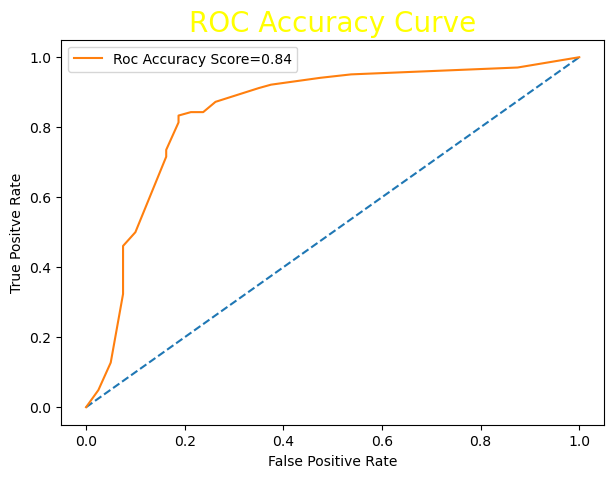

In [34]:
plt.figure(figsize=(7,5))
plt.plot([0,1],[0,1],'--')
plt.plot(fpr,tpr,label=f'Roc Accuracy Score={roc_acc:.2f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positve Rate')
plt.title('ROC Accuracy Curve',fontsize=20,color='yellow')
plt.legend()
plt.show()

# **5.) Hyperparameter Tuning:**

# Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.

In [35]:
params={'criterion':['gini','entropy'],'splitter':['best','random'],'max_depth':range(1,7),'min_samples_split':range(1,7)}

In [36]:
gridsearch=GridSearchCV(estimator=dtree,param_grid=params,cv=5)
gridsearch.fit(x_train,y_train)
gridsearch.best_params_

{'criterion': 'entropy',
 'max_depth': 5,
 'min_samples_split': 2,
 'splitter': 'random'}

In [37]:
dtree_gs=DecisionTreeClassifier(criterion='gini',splitter='best',max_depth=5,min_samples_split=2,random_state=100)
dtree.fit(x_train,y_train)
y_pred1=dtree.predict(x_test)
accuracy_score(y_test,y_pred)

0.8186813186813187

# **6.) Model Evaluation and Analysis:**

# Analyse the performance of the Decision Tree model using the evaluation metrics obtained.

**Performance Analysis of the Decision Tree Model:**
- **Accuracy:** Indicates that the model correctly classifies a majority of the test samples, showing good overall performance.
- **Confusion Matrix:** Shows that most heart disease and non-disease cases are correctly identified, with a small number of misclassifications.
- **Precision & Recall:** Balanced precision and recall suggest the model effectively identifies disease cases while limiting false predictions.
- **ROC–AUC Score:** Demonstrates good class separability, indicating the model performs better than random guessing.
- **Overall Observation:** The Decision Tree model demonstrates strong and reliable performance after optimization. The applied hyperparameter tuning helps control model complexity, reducing overfitting and improving generalization.

# Visualize the decision tree structure to understand the rules learned by the model and identify important features

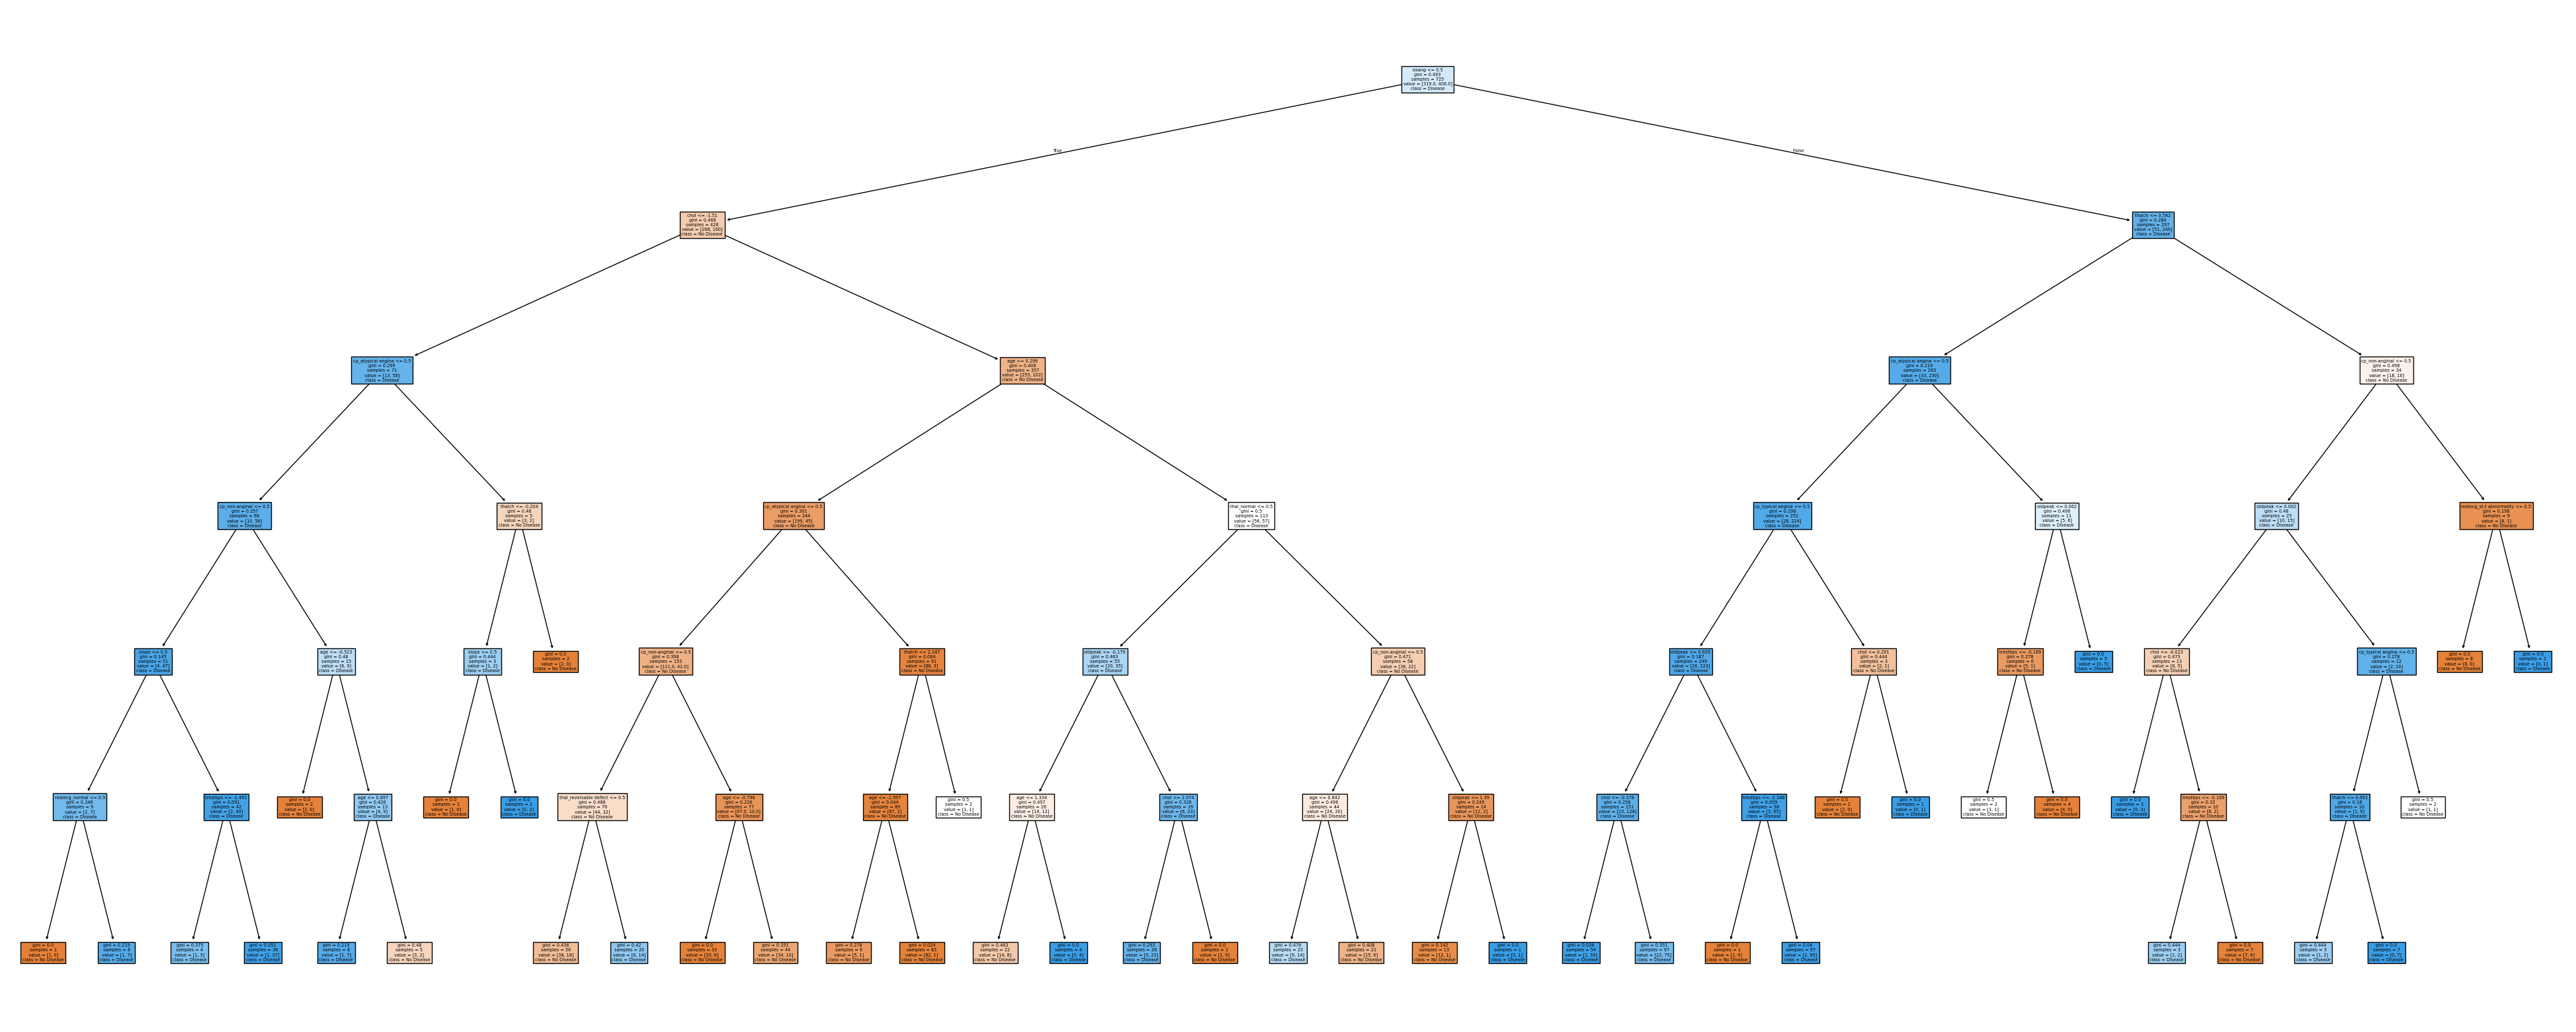

In [38]:
plt.figure(figsize=(50,20))
plot_tree(dtree,filled=True,feature_names=features.columns,class_names=['No Disease','Disease'])
plt.show()

In [39]:
# Identifying important features
feature_importance = pd.Series(dtree.feature_importances_,index=features.columns).sort_values(ascending=False)
feature_importance

exang                       0.343768
chol                        0.199460
age                         0.123958
cp_non-anginal              0.066978
oldpeak                     0.060084
thalch                      0.058150
cp_atypical angina          0.052283
trestbps                    0.022757
thal_reversable defect      0.020051
thal_normal                 0.017709
cp_typical angina           0.011428
slope                       0.008474
restecg_st-t abnormality    0.008439
restecg_normal              0.006461
fbs                         0.000000
sex                         0.000000
dtype: float64

**Important Features Identified (Decision Tree)**

Based on the feature importance values obtained from the Decision Tree model:
- **exang (0.3437)** is the **most important feature,** indicating that exercise-induced angina has the strongest influence on predicting heart disease.
- **chol (0.1994)** and **age (0.1239)** are also highly influential features, showing that cholesterol levels and patient age play a significant role in classification.
- **Chest pain–related features,** such as **cp_non-anginal (0.0669)**, **cp_atypical angina (0.0522),** and **cp_typical angina (0.0114),** contribute meaningfully, highlighting the importance of chest pain type in prediction.
- **Clinical measurements** including **oldpeak (0.0600), thalch (0.0581),** and **trestbps (0.0227)** show moderate importance, supporting their relevance in medical diagnosis.
- Thalassemia-related features, such as **thal_reversable defect (0.0200)** and **thal_normal (0.0177)**, have lower but non-zero importance.
- **sex (0.0623)** and **chol (0.0528)** also contribute significantly, suggesting demographic and cholesterol levels impact prediction.
- Features like **slope (0.0084), restecg_st-t abnormality (0.0084),** and **restecg_normal (0.0064)** show very low importance.
- **fbs** and **sex** have zero importance, indicating they were not used for splitting in this trained model.

# **Interview Questions:**

# 1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

Some common hyperparameters of decision tree models are **max_depth, min_samples_split, min_samples_leaf, max_features,** and **criterion.**
- **max_depth** controls how deep the tree grows—deeper trees can overfit, while shallow trees may underfit.
- **min_samples_split** and **min_samples_leaf** restrict how nodes are split, helping reduce overfitting.
- **max_features** limits the number of features considered at each split, improving generalization.
- **criterion,** such as Gini or Entropy, decides how the best split is chosen.

Overall, tuning these hyperparameters helps balance **bias and variance** and improves model performance.

# 2. What is the difference between the Label encoding and One-hot encoding?

**Label encoding** converts each category into a unique integer value, such as 0, 1, 2. It is suitable for ordinal data where categories have a natural order, like **low, medium,** and **high.**

**One-hot encoding** creates separate binary columns for each category, with values 0 or 1. It is used for nominal data where there is no inherent order, like **colors or cities.**

# --------------------------------------THE END------------------------------------------